# Исследование данных о пользователях сервиса аренды самокатов

**Описание проекта:** Сервис аренды самокатов GoFast предоставляет пользователям два основных тарифа: без подписки и с подпиской Ultra. Каждый тариф имеет свои особенности стоимости поездок.  Это исследование поможет оптимизировать тарифные планы, а также разработать стратегию удержания и привлечения клиентов.

**Цель исследования:** Изучение предпочтений клиентов сервиса и проверка гипотез, которые могут способствовать росту бизнеса. 

**Ход исследования:**
- Подготовка данных: загрузка и изучение предоставленного массива данных, включая таблицы с информацией о пользователях, поездках и тарифах.
- Предобработка данных: обработка пропущенных значений, корректировка типов данных, устранение дубликатов и выявление аномалий.
- Анализ данных: исследование поведения пользователей в зависимости от выбранного тарифа, частоты и длительности поездок, а также других факторов.
- Проверка гипотез: исследование гипотез о характерном поведении с точки зрения использования сервиса самокатов  и доходах от группы клиентов с подпиской.
- Общий вывод: резюмирование результатов анализа, формулировка ключевых выводов и рекомендаций по улучшению тарифных планов и стратегии удержания клиентов.

**Данные:** В рамках данного исследования доступен массив данных о пользователях из нескольких крупных городов, их поездках, а также информация о применяемых тарифах. \
`users_go` - информация о пользователях (имя, возраст, город, тип подписки) \
`rides_go` - информация о поездках (дата, расстояние, время) \
`subscriptions_go` - информация о тарифах 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from scipy import stats as st
from scipy.stats import binom, norm

from math import sqrt

from src.data_prepare import data_info, monthly_income
from src.visualization import (pie_value_counts,
                               barh_value_counts,
                               hist,
                               density_hist)

pd.options.display.float_format = '{:,.2f}'.format


## Загрузка данных

Таблица `users_go` - информация о пользователях.

In [2]:
users_go = pd.read_csv('data/users_go.csv')
data_info(users_go)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 1565 строк × 5 столбцов


,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


,count,mean,std,min,25%,50%,75%,max
user_id,"1,565.00",762.63,443.26,1.00,378.00,762.00,"1,146.00","1,534.00"
age,"1,565.00",24.92,4.55,12.00,22.00,25.00,28.00,43.00


Пропущенные значения:
Пропущенных значений нет.
Наличие дубликатов:
Найдено дубликатов: 31 (1.98%)


В таблице с информацией о пользователях содержится 1565 записей. Типы данных соответствуют значениям и не требуют корректировок, пропусков нет. В поле `age` медиана (25 лет) очень близка к среднему значению (24.92 года), что свидетельствует об однородности в данных и отсутствии явных аномалий и выбросов.

В таблице есть явные дубликаты, удалим их.

In [3]:
print('Кол-во строк в датасете до удаления дублей:', users_go.shape[0])
users_go = users_go.drop_duplicates()
print('Кол-во строк в датасете после удаления дублей:', users_go.shape[0])


Кол-во строк в датасете до удаления дублей: 1565
Кол-во строк в датасете после удаления дублей: 1534


Таблица `rides_go` - информация о поездках пользователей.

In [4]:
rides_go = pd.read_csv('data/rides_go.csv', parse_dates=['date'])
data_info(rides_go)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 18068 строк × 4 столбцов


,user_id,distance,duration,date
0,1,"4,409.92",25.60,2021-01-01
1,1,"2,617.59",15.82,2021-01-18


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


,count,mean,min,25%,50%,75%,max,std
user_id,"18,068.00",842.87,1.00,487.00,889.00,"1,213.25","1,534.00",434.73
distance,"18,068.00","3,070.66",0.86,"2,543.23","3,133.61","3,776.22","7,211.01","1,116.83"
duration,"18,068.00",17.81,0.50,13.60,17.68,21.72,40.82,6.09
date,18068,2021-06-30 19:47:21.266327296,2021-01-01 00:00:00,2021-04-02 00:00:00,2021-06-30 00:00:00,2021-09-28 00:00:00,2021-12-30 00:00:00,NaN


Пропущенные значения:
Пропущенных значений нет.
Наличие дубликатов:
Явных дубликатов нет


В таблице содержится информация о 18068 поездках за весь 2021 год (с 01.01. по 30.12.). Типы данных соответствуют значениям, пропусков нет. Средние и медианные значения для непрерывных переменных достаточно близки, что может свидетельствовать об отсутствии значительных выбросов и аномалий. При этом необходимо при анализе внимательнее рассмотреть крайние значения для исключения возможных ошибок.

Таблица `subscriptions_go` - информация о стоимости поездки: с подпиской и без.

In [5]:
subscriptions_go = pd.read_csv('data/subscriptions_go.csv')
data_info(subscriptions_go, detailed=False)


ОБЗОР ДАТАСЕТА
Основная информация:
Размер данных: 2 строк × 4 столбцов


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 196.0+ bytes


,count,mean,std,min,25%,50%,75%,max
minute_price,2.00,7.00,1.41,6.00,6.50,7.00,7.50,8.00
start_ride_price,2.00,25.00,35.36,0.00,12.50,25.00,37.50,50.00
subscription_fee,2.00,99.50,140.71,0.00,49.75,99.50,149.25,199.00


В таблице содержится 2 строки: информация о стоимости поездки с подпиской и без. Для стоимости указан целочисленный тип данных. Оставим тип без изменений, т.к. в данном случае стоимость выражается целым числом, хотя в целом для цены логичнее использовать float.

<b>Вывод по разделу "Загрузка данных"</b>

После изучения общей информации о данных можно отметить:
- в данных отсутствуют пустые значения 
- типы данных соответствует значениям и не требует изменений
- из таблицы `users_go` с информацией о пользователях сервиса удалены явные дубликаты.

## Предобработка данных

Из общей информации мы увидели, что размер датасета совпадает с количеством непустых строк. Пропущенных значений в датасетах нет. Дополнительно исследуем значения на наличие неявных дубликатов.

- В таблице `users_go` должны быть только уникальные id, поэтому размер датасета должен соответствовать количеству id.
- Категориальные данные в полях `city`, `subscription_type`, `name` не должны содержать неявных дублей.

In [6]:
print('Кол-во строк в датасете:', users_go.shape[0])
print('Кол-во уникальных id:', users_go['user_id'].nunique())


Кол-во строк в датасете: 1534
Кол-во уникальных id: 1534


In [7]:
print(users_go['subscription_type'].unique())
print(subscriptions_go['subscription_type'].unique())


['ultra' 'free']
['free' 'ultra']


In [8]:
users_go['name'].unique()


array(['Кира', 'Станислав', 'Алексей', 'Константин', 'Адель', 'Регина',
       'Игорь', 'Юрий', 'Ян', 'Валерий', 'Агата', 'Марк', 'Ева',
       'Антонина', 'Валерия', 'Амалия', 'Даниил', 'Аделина', 'Святогор',
       'Борис', 'Вероника', 'Ростислав', 'Назар', 'Эдуард', 'Василий',
       'Денис', 'Тамара', 'Николай', 'Эвелина', 'Федор', 'Руслан', 'Иван',
       'Любовь', 'Ярослава', 'Майя', 'Ильдар', 'Данила', 'Нина',
       'Стефания', 'Ясмина', 'Дмитрий', 'Александр', 'Одиссей', 'Арсений',
       'Алла', 'Таисия', 'Максим', 'Юлиана', 'Павел', 'Карина', 'Алиса',
       'Лидия', 'Рамиль', 'Родион', 'Ника', 'Оксана', 'Анастасия',
       'Маргарита', 'Вера', 'Тимур', 'Никита', 'Лев', 'Влад', 'Артур',
       'Анна', 'Ольга', 'Вячеслав', 'Ксения', 'Виталина', 'Владислав',
       'Тамерлан', 'Амина', 'Вадим', 'Олеся', 'Зарина', 'Егор', 'Гордей',
       'Лилия', 'Святослав', 'Роберт', 'Амир', 'Влада', 'Богдан',
       'Полина', 'Марат', 'Елисей', 'Макар', 'Алина', 'Глеб', 'Андрей',
       'Ал

In [9]:
users_go['city'].unique()


array(['Тюмень', 'Омск', 'Москва', 'Ростов-на-Дону', 'Краснодар',
       'Пятигорск', 'Екатеринбург', 'Сочи'], dtype=object)

<b>Вывод по разделу "Предобработка данных"</b>

В ходе предобработки данных дополнительно убедились, что категориальные поля не содержат неявных дубликатов.

## Исследовательский анализ данных

Посмотрим внимательнее на распределение пользователей по ключевым характеристикам.

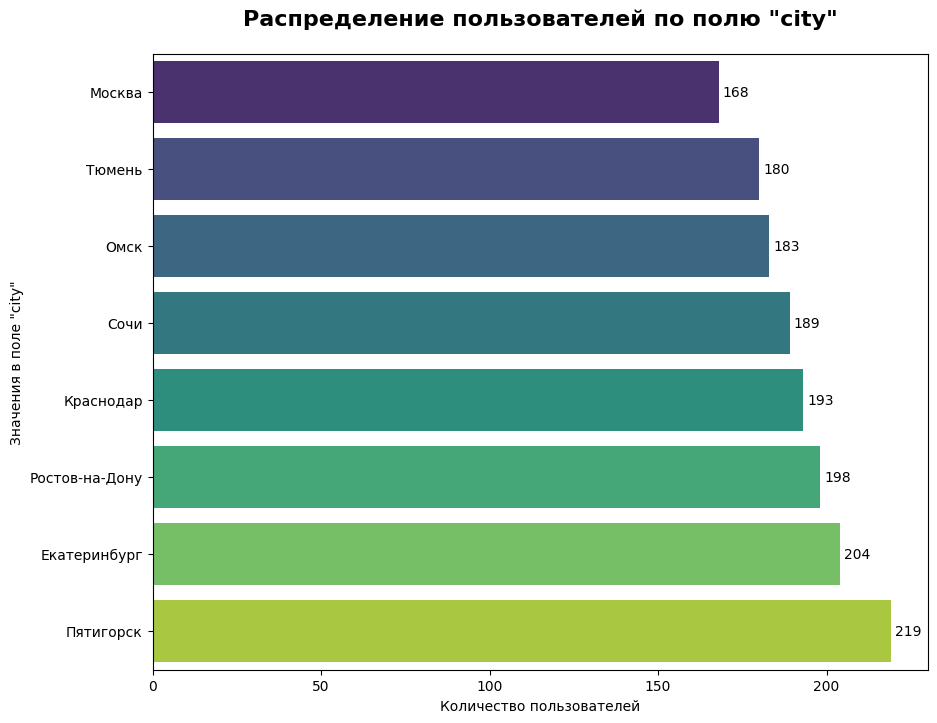

In [10]:
barh_value_counts(users_go, 'city')


Во всех городах представленных в данных более 160 пользователей сервиса. Наибольшее количество клиентов в Пятигорске (219), а наименьшее - в Москве (168).

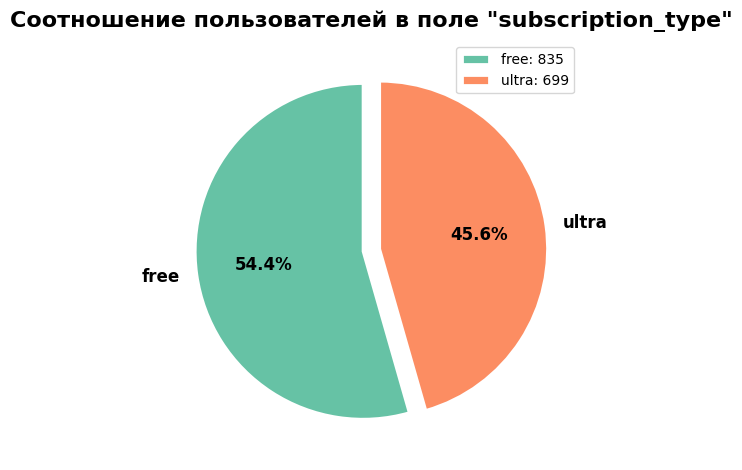

In [11]:
pie_value_counts(users_go, 'subscription_type')


Бесплатные пользователи составляют 54.4% от общего числа клиентов, пользователи с подпиской - 45.6%

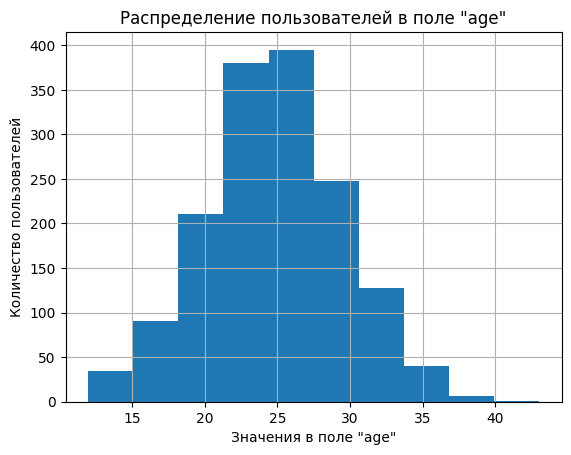

In [12]:
hist(users_go, 'age')


Данные о возрасте распределены нормально. Явных аномалий по возрасту в данных нет. Больше всего пользователей представлено в диапазоне 25-28 лет. Размах набора данных 12-43 года.

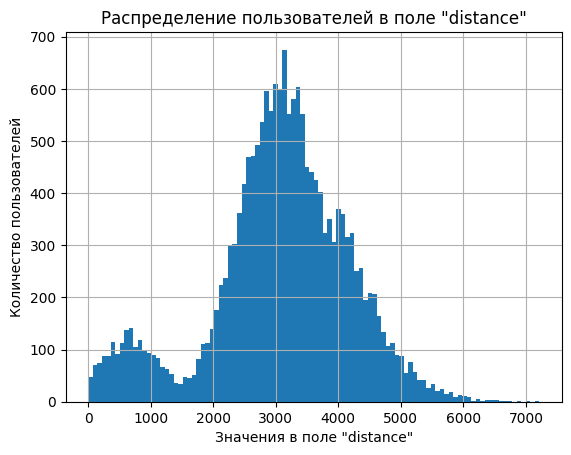

In [13]:
hist(rides_go, 'distance', bins=100)


Из описания данных и гистограммы видим, что значительных выбросов в данных о расстоянии нет. Среднее значение не сильно отличается от медианы, что также косвенно подтверждает отсутствие значимых выбросов. На гистограмме четко видны 2 пика. Первый - меньшего размера - соответствует коротким поездкам (600-700м) и второй - с расстоянием около 3 км. Максимальное расстояние за одну поездку составило 7,2 км.

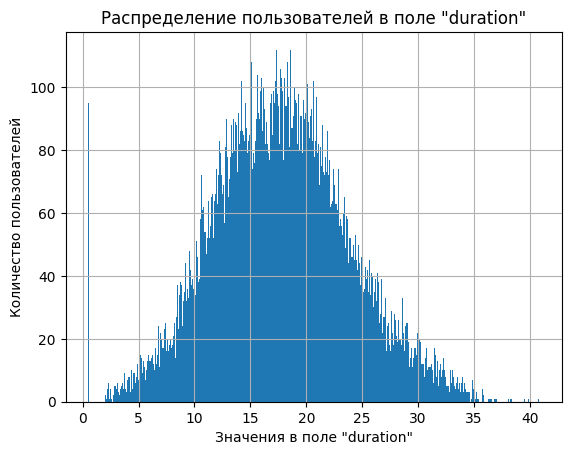

In [14]:
hist(rides_go, 'duration', bins=500)


На гистограмме есть ярко выраженный выброс по времени пользования менее одной минуты, который соответствует минимальному значению в данных - 0.5. Рассмотрим эти данные подробнее.

In [15]:
print('Среднее расстояние для поездок до 1 мин:', \
      rides_go[rides_go['duration'] < 1]['distance'].mean())
print('Количество поездок до 1 мин:', \
     rides_go[rides_go['duration'] < 1]['user_id'].count())


Среднее расстояние для поездок до 1 мин: 5113.176548536017
Количество поездок до 1 мин: 95


Помимо явно выделяющейся продолжительности, эти поездки имеют аномальное среднее расстояние. Проехать в среднем 5 км менее, чем за 1 минуту невозможно. Однако, в случае с данными о пользователях, которые используют самокаты, если оплата за эти данные была получена, то они представляют собой реальные наблюдения, а не аномалии или выбросы. Удаление таких наблюдений может привести к потере важной информации и возможным искажениям результатов и выводов на основе анализа данных.

Поэтому на текущем этапе оставим данные без изменений и сообщим о наличии возможных проблем ответственным сотрудникам.

<b>Вывод по разделу "Исследовательский анализ данных" </b>

1. Проанализированы данные о количестве пользователей в городах. В ТОП-5 по количеству пользователей преимущественно попадают города с теплым климатом. Исключение - Екатеринбург, кторый занимает вторую строчку. Меньше всего пользователей в Москве.

2. Пользователей без подписки в данных больше: бесплатные пользователи составляют 54.4% от общего числа клиентов, пользователи с подпиской - 45.6%

3. Чаще всего расстояние составляет около 3 км. Также в данных присутствует второй, менее выраженный пик, который соответствует поездкам до 1 км. Вероятно, это могут быть поездки от остановки до дома, например.

4. Среднее время поездки совпадает с медианным и составляет около 18 минут. В данных присутствуют аномальные значения, которые на данном этапе оставлены без изменений, чтобы не искажать результаты и выводы.

## Объединение данных

У одного пользователя может быть несколько поездок поэтому для объединения используем тип `outer`. 

In [16]:
print('Размер датасета до объединения:', rides_go.shape[0])
all_rides = users_go.merge(rides_go, how='outer', on='user_id')
print('Размер датасета после объединения:', all_rides.shape[0])


Размер датасета до объединения: 18068
Размер датасета после объединения: 18068


Для дальнейшего расчета прибыли добавим информацию о стоимости подписок.

In [17]:
all_rides = all_rides.merge(subscriptions_go, how='left', on='subscription_type')
print(all_rides.shape)
all_rides.head(2)


(18068, 11)


,user_id,name,age,city,subscription_type,distance,duration,date,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,"4,409.92",25.60,2021-01-01,6,0,199
1,1,Кира,22,Тюмень,ultra,"2,617.59",15.82,2021-01-18,6,0,199


Посмотрим на соотношение количества поездок клиентов с подпиской и без.

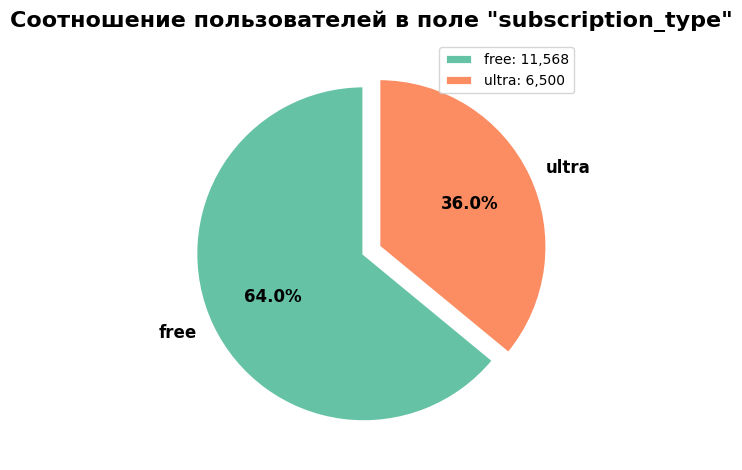

In [18]:
pie_value_counts(all_rides, 'subscription_type')


Мы видим, что количество поездок без подписки почти в 2 раза выше, чем по подписке, что создает несбалансированные группы. Для корректного сравнения форм распределений (а не абсолютных количеств) мы используем нормализованную гистограмму плотности с параметрами stat="density" и common_norm=False.

Нормализация преобразует гистограмму так, что площадь под каждым распределением равна 1, показывая относительную частоту значений внутри каждой группы. Каждая группа нормализуется отдельно, что позволяет сравнивать их формы независимо от размера выборки.

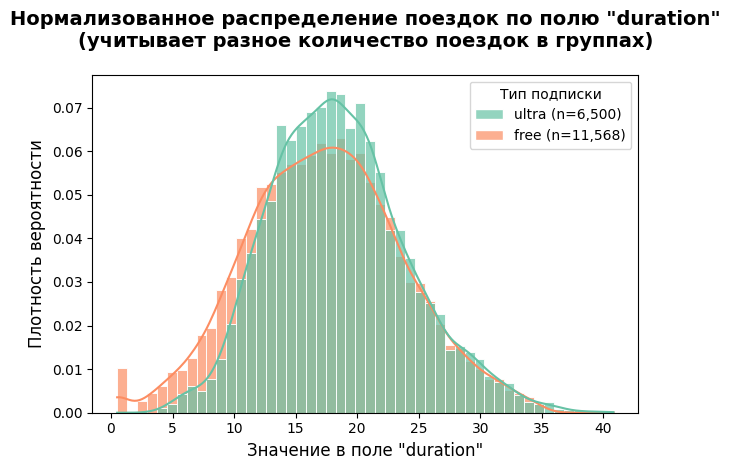

In [19]:
density_hist(all_rides, 'duration', 'subscription_type')


In [20]:
print('Длительность поездок для пользователей с подпиской:\n', \
      all_rides.query('subscription_type == "ultra"')['duration'].describe(), '\n')

print('Длительность поездок для пользователей без подписки:\n', \
      all_rides.query('subscription_type == "free"')['duration'].describe(), '\n')


Длительность поездок для пользователей с подпиской:
 count   6,500.00
mean       18.54
std         5.57
min         3.76
25%        14.52
50%        18.18
75%        21.88
max        40.82
Name: duration, dtype: float64 

Длительность поездок для пользователей без подписки:
 count   11,568.00
mean        17.39
std          6.33
min          0.50
25%         12.96
50%         17.33
75%         21.59
max         34.95
Name: duration, dtype: float64 



Продолжительность поездок для пользователей с подпиской и без имеет схожее распределение. Оба распределения имеют основной пик примерно в районе ~ 13-20 минут. Средняя продолжительность выше для пользователей с подпиской на 1 минуту. Минимальная и максимальная продолжительность так же выше для пользователей с подпиской. У поездок без подписки при этом выше вариативность, на графике это видно как более выраженный "хвост" в левой части.

Посмотрим на распределения по плотности для расстояния поездок.

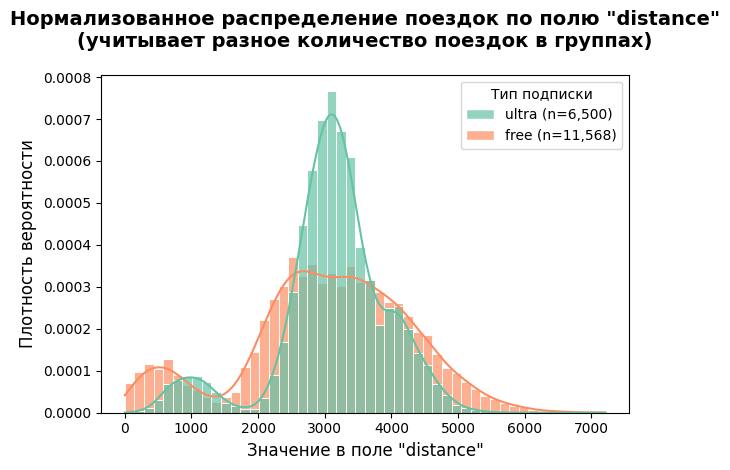

In [21]:
density_hist(all_rides, 'distance', 'subscription_type')


In [22]:
print('Расстояние поездок для пользователей с подпиской:\n', \
      all_rides.query('subscription_type == "ultra"')['distance'].describe(), '\n')

print('Расстояние поездок для пользователей без подписки:\n', \
      all_rides.query('subscription_type == "free"')['distance'].describe(), '\n')


Расстояние поездок для пользователей с подпиской:
 count   6,500.00
mean    3,115.45
std       836.90
min       244.21
25%     2,785.44
50%     3,148.64
75%     3,560.57
max     5,699.77
Name: distance, dtype: float64 

Расстояние поездок для пользователей без подписки:
 count   11,568.00
mean     3,045.50
std      1,246.17
min          0.86
25%      2,366.56
50%      3,114.65
75%      3,905.70
max      7,211.01
Name: distance, dtype: float64 



Расстояние поездок для пользователей с подпиской и без также имеет схожее распределение, но здесь различия более выражены. Для пользователей с подпиской в среднем характерны более длительные поездки: они чаще совершают поездки вокруг "типовой" дистанции (~ 3 км). Клиенты без подписок хоть и имеют схожие пики по дистанции поездки, но в целом их поездки более разнообразны - от очень коротких до очень длинных. 

<b>Вывод по разделу "Объединение данных"</b>

1. В датасет `all_rides` объединены данные обо всех пользователях и их поездках, а также стоимость пользования сервисом в зависимости от наличия или отсутствия подписки.

2. Проанализированы данные о расстоянии и продолжительности поездок для каждой категории пользователей (с подпиской и без). Среднее время и продолжительность для обеих категорий схожи, данные имеют похожее распределение. Однако, можно заметить, что различия между группами сильнее проявляются в расстоянии поездок. Для пользователей с подписками характерны чуть более длительыне поездки. Для клиентов без подписок часто встречются аномально короткие поездки (и по времени и по расстоянию), которые могут быть отменами, ошибками или результатом акционных предложений. 

## Подсчёт выручки

Создадим таблицу с агрегированными данными за каждый месяц: суммарное время и расстояние для каждого пользователя. Для удобства предварительно выделим месяц в отдельную колонку. 

In [23]:
all_rides['month'] = all_rides['date'].dt.month

all_rides_sum = (all_rides
        .groupby(['user_id', 'month']).agg(
                                {'duration': ['sum'],
                                 'distance': ['sum'],
                                 'user_id': ['count'], 
                                 'subscription_type':['max']})
        .droplevel(1,axis=1) 
        .rename(columns={'duration': 'Общее время поездок',
                      'distance': 'Общая дистанция поездок',
                      'user_id': 'Количество поездок',
                      'subscription_type': 'Наличие подписки'})
)

display(all_rides_sum.head(2))
print('Кол-во пользователей с подпиской:', \
      all_rides_sum[all_rides_sum['Наличие подписки'] == "ultra"]['Наличие подписки'].count())
print('Кол-во пользователей без подписки:', \
      all_rides_sum[all_rides_sum['Наличие подписки'] == "free"]['Наличие подписки'].count())


Общее время поездок  Общая дистанция поездок  \
user_id month                                                 
1       1                    41.42                 7,027.51   
        4                     6.23                   754.16   

               Количество поездок Наличие подписки  
user_id month                                       
1       1                       2            ultra  
        4                       1            ultra

Кол-во пользователей с подпиской: 4533
Кол-во пользователей без подписки: 6798


Округлим время поездок в большую сторону, т.к. оплата поминутная и списывается с начала каждой минуты.

In [24]:
all_rides_sum['Общее время поездок'] = np.ceil(all_rides_sum['Общее время поездок'])


In [25]:
all_rides_sum = monthly_income(all_rides_sum)

display(all_rides_sum.head()) 
display(all_rides_sum.query('user_id == 1'))


Общее время поездок  Общая дистанция поездок  \
user_id month                                                 
700     1                    15.00                 2,515.69   
        2                    86.00                13,446.66   
        3                    19.00                 3,798.33   
        4                    16.00                 2,984.55   
        6                    29.00                 5,927.65   

               Количество поездок Наличие подписки  Месячная выручка  
user_id month                                                         
700     1                       1             free            170.00  
        2                       5             free            938.00  
        3                       1             free            202.00  
        4                       1             free            178.00  
        6                       2             free            332.00

Общее время поездок  Общая дистанция поездок  \
user_id month                                                 
1       1                    42.00                 7,027.51   
        4                     7.00                   754.16   
        8                    45.00                 6,723.47   
        10                   32.00                 5,809.91   
        11                   54.00                 7,003.50   
        12                   28.00                 6,751.63   

               Количество поездок Наличие подписки  Месячная выручка  
user_id month                                                         
1       1                       2            ultra            451.00  
        4                       1            ultra            241.00  
        8                       2            ultra            469.00  
        10                      2            ultra            391.00  
        11                      3            ultra            523.00  
        12                      2            ultra            367.00

<b>Вывод по разделу "Подсчёт выручки"</b>

1. Сформирована агрегированная помесячная таблица для каждого пользователя с информацией о суммарном времени, расстояниии и количестве поездок.

2. Общее время поездок округлили в большую сторону, т.к. оплата поминутная и списывается с начала каждой минуты.

3. Рассчитана помесячная выручка с учетом наличия подпсики и без по следующей формуле: стоимость старта поездки × количество поездок + стоимость одной минуты поездки × общая продолжительность всех поездок в минутах + стоимость подписки.

## Проверка гипотез

### Гипотеза №1

**Тратят ли пользователи с подпиской больше времени на поездки?**

Сформулируем нулевую и альтернативную гипотезы:

H0: Среднее время поездки для пользователей с подпиской равно среднему времени поездки для пользователей без подписки ($\mu$ = 17,33).

H1: Среднее время поездки для пользователей с подпиской больше среднего времени поездки для пользователей без подписки ($\mu$ > 17,33).

Т.к. у нас две независимых генеральных совокупности (пользователи с подпиской и без) для проверки гипотезы используем метод `scipy.stats.ttest_ind`. Одним из важных параметров этого метода является равенство дисперсий. Из анализа общей информации о продолжительности поездок для обеих категорий мы знаем, что стандартные отклонения, а следовательно и дисперсии для совокупностей не равны. Следовательно, установим при проверке следущий параметр: `equal_var=False`.

Уровень значимости - 5%. Альтернативная гипотеза - правосторонняя.

In [26]:
alpha = 0.05
results = st.ttest_ind(all_rides.query('subscription_type == "ultra"')['duration'],
                       all_rides.query('subscription_type == "free"')['duration'],
                       equal_var=False,
                       alternative='greater')

print(f'p-value: {results.pvalue:.5f}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')


p-value: 0.00000
Отвергаем нулевую гипотезу


**Вывод**: Полученное значение p-value меньше заданного уровня значимости, поэтому можно отвергнуть нулевую гипотезу. Есть основания говорить, что продолжительность поездок у пользователей с подпиской выше, чем у пользователей без.

### Гипотеза №2

**Среднее расстояние для пользователей с подпиской за одну поездку, не превышает 3130 метров (оптимальное расстояние с точки зрения износа самоката)?**

Поскольку оптимальное расстояние по износу составляет 3130 м, значит большее расстояние приводит к повышенному износу самоката. Следовательно, имеет смысл сформулировать альтернативную гипотезу "Подписчики в среднем проезжают расстояние больше оптимального" и соответственно в статистическом тесте использовать параметр: `alternative = 'greater'`.

Сформулируем нулевую и альтернативную гипотезы:

H0: Среднее расстояние для пользователей с подпиской равно 3130 м  ($\mu$ = 3130).

H1: Среднее расстояние для пользователей с подпиской больше 3130 м ($\mu$ > 3130).

В данном случае нас интересуют только пользователи с подпиской, поэтому для проверки гипотезы используем метод `scipy.stats.ttest_1samp()`.

Уровень значимости - 5%. Альтернативная гипотеза - правосторонняя.

In [27]:
alpha = 0.05 
optimal_distance = 3130

results = st.ttest_1samp(
    all_rides.query('subscription_type == "ultra"')['distance'], 
    optimal_distance,
    alternative='greater')

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу') 


p-значение: 0.9195368847849785
Не отвергаем нулевую гипотезу


**Вывод**: Полученное значение p-value больше заданного уровня значимости, поэтому мы не отвергаем нулевую гипотезу. Нет оснований утверждать, что среднее расстояние подписчиков превышает оптимальное расстояние с точки зрения износа самоката.

### Гипотеза №3

**Помесячная выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки?**

Используем метод `scipy.stats.ttest_ind` для двух независимых генеральных совокупностей. Т.к. мы знаем, что стандартное отклонение и, как следствие, дисперсия для совокупностей не равны в случае с расстоянием и временем поездки, то есть основания полагать, что они не равны и в случае с выручкой. Установим при проверке следущий параметр: `equal_var=False`.

Сформулируем нулевую и альтернативную гипотезы:

H0: Средняя помесячная выручка от пользователей с подпиской равна средней помесячной выручке для пользователей без подписки.

H1: Средняя помесячная выручка от пользователей с подпиской больше средней помесячной выручки для пользователей без подписки.

Уровень значимости - 5%. Альтернативная гипотеза - правосторонняя.

In [28]:
alpha = 0.05

income_subscription = all_rides_sum.loc[all_rides_sum['Наличие подписки'] == 'ultra', 'Месячная выручка']
income_non_subscription = all_rides_sum.loc[all_rides_sum['Наличие подписки'] == 'free', 'Месячная выручка']

results = st.ttest_ind(income_subscription,
                       income_non_subscription,
                       equal_var=False,
                       alternative='greater')

print(f'p-value: {results.pvalue:.5f}')

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')


p-value: 0.00000
Отвергаем нулевую гипотезу


**Вывод**: Полученное значение p-value меньше заданного уровня значимости, поэтому можно отвергнуть нулевую гипотезу. Есть основания говорить, что среднемесячная выручка клиентов с подпиской выше, чем у пользователей без подписки.

### Гипотеза №4

**После обновления серверов мобильного приложения количество обращений в тех.поддержку снизилось?**

Предполагается, что у нас есть данные по количеству обращений до и после обновления серверов. Здесь нам необходимо использовать односторонний тест, потому что нас интересует только одно направление изменения (уменьшилось ли количество обращений или нет). 
Основная (нулевая) гипотеза в этом случае может утверждать, что различия между количеством обращений до и после обновления отсутствуют или что количество обращений после обновления больше или равно, чем до. Альтернативная гипотеза будет утверждать, что количество обращений после обновления меньше, чем до обновления.

Сформулируем нулевую и альтернативную гипотезы:

H0: Среднее количество обращений в тех.поддержку до обновления и после обновления серверов равны ($\mu1$ = $\mu2$).

H1: Среднее количество обращений в тех.поддержку после обновления серверов меньше, чем среднее количество обращений до ($\mu1$ > $\mu2$).

В данном случае это одна генеральная совокупность пользователей сервиса до и после изменения, т.е. зависимые (парные) выборки. Необходимо использовать метод `scipy.stats.ttest_rel()`. Методу передается два параметра: наборы данных до и после.

<b>Вывод по разделу "Проверка гипотез"</b>


По итогам проверки гипотез есть основания полагать, что при уровне значимости 5%:

1. Продолжительность поездок у пользователей с подпиской выше, чем у пользователей без.
2. Среднее расстояние поездок у пользователей с подпиской не превышает 3130м.
3. Среднемесячная выручка клиентов с подпиской выше, чем у пользователей без подписки.

## Задачи на распределения

### Задача 1

**Необходимо провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. Какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была ~5 %?**

Каждый промокод - эксперимент Бернулли с двумя исходами:
- клиент продлил подписку - успех
- клиент не продлил подписку - неудача

Вероятность успеха определяется по данным предыдущей акции. После бесплатного пробного периода подписку продлевает 10% клиентов, т.е. вероятность p = 0.1 и одинакова для всех попыток.При этом попытки (выдача промокода) независимы между собой.

Количество попыток - величина n - это то, что нам необходимо определить. Требуется подобрать n таким образом, чтобы вероятность того, что продлят подписку менее 100 пользователей (k<100), была не более 5% (p_k = 0.05). 

Описание задачи соответствует **биномиальному распределению**.

Построим график биномиального распределения с произвольным n. Т.к. нас интересует достаточное большое количество успехов, возьмем n=1000.

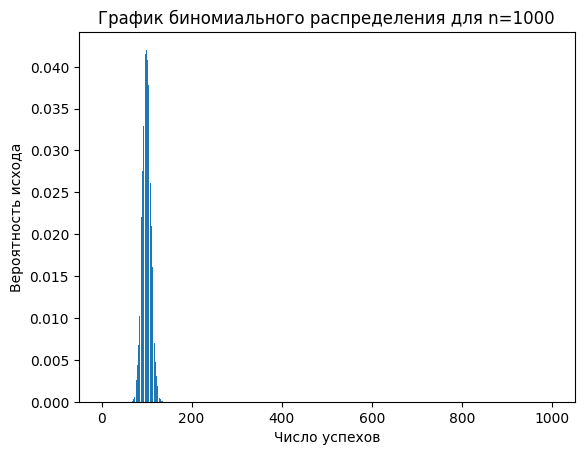

In [29]:
n = 1000
p = 0.1

distr = []

for k in range(0, n + 1):
    current_value = binom.pmf(k, n, p)
    distr.append(current_value)
    
plt.bar(range(0, n + 1), distr)
plt.title('График биномиального распределения для n=1000')
plt.xlabel('Число успехов')
plt.ylabel('Вероятность исхода')
plt.show()


По графику видим, что при 1000 попыток количество успехов будет около 100. С помощью метода cdf вычислим точное количество необходимых попыток, чтобы получить вероятность 5%, что количество успешных исходо будет менее 100.

In [30]:
n = 1000
p = 0.1
k = 100 - 1
p_k = 0.05 

while binom.cdf(k, n, p) > p_k:
    n += 1
print(f'Минимальное количество промокодов, чтобы вероятность не выполнить план была <= 5%: {n}')


Минимальное количество промокодов, чтобы вероятность не выполнить план была <= 5%: 1161


### Задача 2

**С какой вероятностью при рассылке 1 млн. push-уведомлений их откроют не более 399,5 тыс. пользователей?**

Каждое push-уведомление так же можно интерпретировать как эксперимент Бернулли с двумя исходами:
- клиент открыл уведомление - успех
- клиент не открыл уведомление - неудача

Известно, что уведомления открывают 40% клиентов, т.е. вероятность p = 0.4 и одинакова для всех попыток. При этом попытки (отправка уведомления) независимы между собой.

Количество попыток фиксированная величина n = 1 000 000. Необходимо определить вероятность того, что уведомления откроют не более 399 500 пользователей (k =< 399 500).

Описание задачи соответствует **биномиальному распределению**.

Т.к. в данном случае n велико, проверим условие хорошей аппроксимации к нормальному распределению:

In [31]:
n = 1000000
p = 0.4
k = 399500

mu = n * p
sigma = sqrt(n * p * (1 - p))


In [32]:
if (mu - (3 * sigma) >= 0) and ((mu + (3 * sigma) <= n)):
    print('Условие выполняется')
else:
    print('Условие не выполняется')


Условие выполняется


Следовательно, мы можем аппроксимировать биномиальное распределение нормальным и рассчитать необходимую вероятность с помощью метода cdf.

In [33]:
distr = st.norm(mu, sigma) 
result = distr.cdf(k)
print(f'Вероятность получить не более {k} переходов при рассылке {n} уведомлений: \
{result * 100:.2f}%')


Вероятность получить не более 399500 переходов при рассылке 1000000 уведомлений: 15.37%


Построим график для визуализации результата:

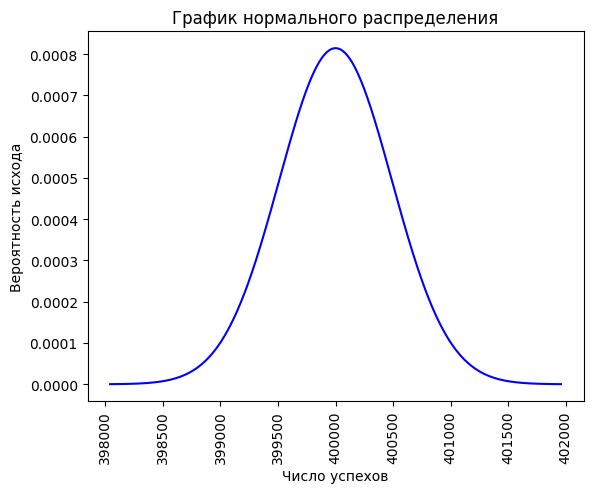

In [34]:
arange = np.arange((mu - 4 * sigma),(mu + 4 * sigma),1)
plt.plot(arange, st.norm.pdf(arange, mu, sigma), 'b-')
plt.xticks(rotation=90)
plt.title('График нормального распределения')
plt.xlabel('Число успехов')
plt.ylabel('Вероятность исхода')
plt.show()
plt.show()


<b>Вывод по разделу "Задачи на распределения"</b>

1. Необходимо разослать как минимум 1161 промокод, чтобы не менее 100 клиентов продлили подписку с вероятностью 95%.

2. При рассылке 1 млн уведомлений, вероятность, что уведомление откроют не более 399,5 тыс. пользователей составит 15,37 %.

## ОБЩИЙ ВЫВОД

В ходе предобработки было сделано следующее:
- Удалены явные дубликаты из таблицы пользователей.
- Убедились в отсутствии неявных дубликатов в категориальных данных .

Для задач анализа данные объединены: \
Создан объединенный датасет `all_rides`, содержащий информацию обо всех поездках и пользователях. Пользователи разделены на две категории (с подпиской и без) в отдельных таблицах: `users_subscription` и `users_non_subscription`.

Проведена агрегация данных:
- Сформированы помесячные таблицы для каждого пользователя, содержащие суммарное время, расстояние и количество поездок.
- Рассчитана месячная выручка на основе стоимости старта поездки, длительности поездок, количества поездок и наличия подписки.

Основные тренды и результаты анализа:

1. Распределение пользователей и поездок:
- ТОП-5 городов по количеству пользователей преимущественно составляют города с теплым климатом, за исключением Екатеринбурга, занимающего второе место. Наименьшее количество пользователей наблюдается в Москве.
- Пользователей без подписки больше, чем с подпиской. Однако пользователи с подпиской генерируют более высокую среднемесячную выручку.

2. Особенности поездок:
- Чаще всего расстояние поездки составляет около 3 км. Второй пик приходится на короткие поездки до 1 км, что может быть связано с поездками «от остановки до дома».
- Средняя продолжительность поездки составляет около 18 минут. Для обеих категорий пользователей продолжительность и расстояние поездок распределены схожим образом, но у пользователей без подписки больше доля коротких поездок.

3. Проверка гипотез (при уровне значимости 5%):
- Пользователи с подпиской совершают более продолжительные поездки.
- Среднее расстояние поездки у подписчиков не превышает 3130 м, что оптимально с точки зрения износа самоката.
- Среднемесячная выручка с пользователей с подпиской выше, чем с пользователей без подписки.
- Даны рекомендации по применению методов для оценки изменений количества обращений в тех.поддержку после обновления серверов мобильного приложения.

**Рекомендации и возможности для дальнейших исследований:**
- Пользователи с подпиской выгоднее для сервиса за счет более длительных поездок и высокой среднемесячной выручки. Необходимо разработать маркетинговую стратегию для привлечения и удержания большего количества пользователей на тарифном плане 'ultra'.
- Рассмотреть возможность введения дополнительных тарифных планов для пользователей без подписки, ориентированных на короткие поездки.
- Изучить причины низкой популярности сервиса в Москве и разработать меры для привлечения пользователей в этом регионе.
- Провести более детальный анализ поведения пользователей с учетом сезонности и особенностей климата городов.

В рамках доп.исследования решены следующие задачи:
- Определен необходимый минимум промокодов на бесплатный месяц пользования сервисом, чтобы не менее 100 клиентов продлили подписку с вероятностью 95% (1161 промокод).
- Определена вероятность того, что при рассылке 1 млн уведомлений, уведомление откроют не более 399,5 тыс. пользователей (15,37%).